# Healthcare Analytics for Doctor Visits

---

**Project Type:** Academic & Portfolio — Exploratory Data Analysis  
**Dataset:** Doctor Visits Survey (5,190 records)  
**Author:** *(your name)*  
**Date:** *(date)*  

---

## Project Overview

This notebook performs a complete exploratory data analysis (EDA) of a healthcare survey
dataset focused on doctor-visit frequency. The dataset contains demographic, health, insurance,
and chronic-condition variables for 5,190 survey respondents.

**The analysis is purely descriptive and exploratory.** No causal claims are made.
Patterns and associations are reported responsibly, with uncertainty and data limitations
documented throughout.

---

> **Ethical Notice:**  
> All findings are statistical patterns only. Correlation does not imply causation.
> These results should not be used for clinical or policy decisions without further
> rigorous analysis and domain expertise.

## 1. Analytical Objectives

This project investigates the following exploratory questions:

1. What is the distribution of doctor visits in this population?
2. What percentage of respondents report zero visits?
3. How does visit frequency vary across age groups?
4. Do respondents reporting illness show different visit counts than those reporting none?
5. What is the relationship between reduced-activity days and visit count?
6. How do limiting vs. non-limiting chronic conditions relate to utilization?
7. Does insurance type relate to visit patterns?
8. How do government-assisted groups compare with privately insured respondents?
9. Does income level appear associated with visit frequency?
10. Are there gender differences in visit frequency?
11. What characterizes zero-visit vs. high-utilizer respondents?
12. How is the self-rated health score associated with visit count?

> These are exploratory questions, not pre-determined hypotheses.

## 2. Dataset Description

| Property | Value |
|---|---|
| **Raw file** | `data/raw/doctor_visits_raw.csv` |
| **Processed file** | `data/processed/doctor_visits_clean.csv` |
| **Rows** | 5,190 |
| **Cleaned columns** | 26 (12 original + 14 engineered) |
| **Missing values** | 0 |

The dataset is consistent with the Doctor Visits dataset from Cameron & Trivedi (1986),
an Australian health survey. Country, year, and exact survey methodology are not
confirmed in the file itself — generalizations to specific populations are not made.

## 3. Data Dictionary

### Original Columns

| Column | Type | Meaning | Notes |
|---|---|---|---|
| `visits` | int | Doctor visits in the reference period | Target variable; zero-inflated |
| `gender` | str | Patient gender | 'female' / 'male' only |
| `age` | float | Age scaled (e.g. 0.19 = 19 yrs) | 12 discrete bands |
| `income` | float | Household income, normalized 0–1.5 | 79 rows = 0 (ambiguous) |
| `illness` | int | Self-reported illness count, past 2 weeks | 0–5 |
| `reduced` | int | Days of reduced activity, past 2 weeks | 14 = ceiling |
| `health` | int | Self-rated health score | 0–12; scale direction unknown |
| `private` | str | Has private insurance | 'yes'/'no' |
| `freepoor` | str | Govt free care (low-income) | 'yes'/'no' |
| `freerepat` | str | Govt free care (repatriated) | 'yes'/'no' |
| `nchronic` | str | Non-limiting chronic condition | 'yes'/'no' |
| `lchronic` | str | Limiting chronic condition | 'yes'/'no' |

### Engineered Columns

| Column | Meaning |
|---|---|
| `age_years` | `age × 100` — year-band label |
| `age_group` | '<=25' / '26-35' / '36-45' / '46-55' / '56-65' / '66+' |
| `income_zero_flag` | 1 if income == 0 |
| `income_group` | Low / Lower-Mid / Upper-Mid / High |
| `*_enc` | Binary 0/1 encodings of yes/no columns |
| `insurance_type` | Single category: Private / Free-Poor / Free-Repatriated / Uninsured |
| `chronic_status` | No Condition / Non-Limiting / Limiting |
| `visit_group` | 0 visits / 1-2 / 3-5 / 6+ |
| `reduced_at_ceiling` | 1 if reduced == 14 |

## 4. Importing Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

PROC_PATH = '../data/processed/doctor_visits_clean.csv'
RAW_PATH  = '../data/raw/doctor_visits_raw.csv'

print('Libraries loaded.')
print(f'pandas {pd.__version__}  |  numpy {np.__version__}')

Libraries loaded.
pandas 3.0.3  |  numpy 2.4.6


## 5. Loading the Processed Dataset

We load the **cleaned** dataset produced in Phase 2.  
The raw file (`data/raw/doctor_visits_raw.csv`) remains unmodified.

In [29]:
df = pd.read_csv(PROC_PATH)

print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Shape: (5190, 26)
Missing values: 0


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,...,private_enc,freepoor_enc,freerepat_enc,nchronic_enc,lchronic_enc,gender_enc,insurance_type,chronic_status,visit_group,reduced_at_ceiling
0,1,female,0.19,0.55,1,4,1,yes,no,no,...,1,0,0,0,0,0,Private,No Condition,1-2 visits,0
1,1,female,0.19,0.45,1,2,1,yes,no,no,...,1,0,0,0,0,0,Private,No Condition,1-2 visits,0
2,1,male,0.19,0.90,3,0,0,no,no,no,...,0,0,0,0,0,1,Uninsured,No Condition,1-2 visits,0
3,1,male,0.19,0.15,1,0,0,no,no,no,...,0,0,0,0,0,1,Uninsured,No Condition,1-2 visits,0
4,1,male,0.19,0.45,2,5,1,no,no,no,...,0,0,0,1,0,1,Uninsured,Non-Limiting,1-2 visits,0


## 6. Descriptive Statistics

This section summarises the shape, types, distributions, and key statistics
of every relevant column in the processed dataset.

In [30]:
print('=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes.to_string())

=== Shape ===
(5190, 26)

=== Data Types ===
visits                  int64
gender                    str
age                   float64
income                float64
illness                 int64
reduced                 int64
health                  int64
private                   str
freepoor                  str
freerepat                 str
nchronic                  str
lchronic                  str
age_years               int64
age_group                 str
income_zero_flag        int64
income_group              str
private_enc             int64
freepoor_enc            int64
freerepat_enc           int64
nchronic_enc            int64
lchronic_enc            int64
gender_enc              int64
insurance_type            str
chronic_status            str
visit_group               str
reduced_at_ceiling      int64


In [31]:
num_cols = ['visits', 'age_years', 'income', 'illness', 'reduced', 'health']

summary = df[num_cols].agg(['count','min','max','mean','median','std']).T
summary.columns = ['count','min','max','mean','median','std']
print('=== Numerical Summary ===')
summary.round(4)

=== Numerical Summary ===


,count,min,max,mean,median,std
visits,5190.0,0.0,9.0,0.3017,0.00,0.7981
age_years,5190.0,19.0,72.0,40.6385,32.00,20.4782
income,5190.0,0.0,1.5,0.5832,0.55,0.3689
illness,5190.0,0.0,5.0,1.4320,1.00,1.3842
reduced,5190.0,0.0,14.0,0.8618,0.00,2.8876
health,5190.0,0.0,12.0,1.2175,0.00,2.1243


In [32]:
cat_cols = ['gender','private','freepoor','freerepat','nchronic','lchronic',
            'age_group','income_group','insurance_type','chronic_status','visit_group']

for col in cat_cols:
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    tbl = pd.DataFrame({'count': vc, 'pct': pct})
    print(f'--- {col} ---')
    print(tbl.to_string())
    print()

--- gender ---
        count   pct
gender             
female   2702  52.1
male     2488  47.9

--- private ---
         count   pct
private             
no        2892  55.7
yes       2298  44.3

--- freepoor ---
          count   pct
freepoor             
no         4968  95.7
yes         222   4.3

--- freerepat ---
           count   pct
freerepat             
no          4099  79.0
yes         1091  21.0

--- nchronic ---
          count   pct
nchronic             
no         3098  59.7
yes        2092  40.3

--- lchronic ---
          count   pct
lchronic             
no         4585  88.3
yes         605  11.7

--- age_group ---
           count   pct
age_group             
<=25        1965  37.9
66+         1137  21.9
26-35        824  15.9
56-65        589  11.3
46-55        403   7.8
36-45        272   5.2

--- income_group ---
                      count   pct
income_group                     
Lower-Mid(0.16-0.45)   2057  39.6
Upper-Mid(0.46-0.75)   1363  26.3
High(0.76-1.50

--- chronic_status ---
                count   pct
chronic_status             
No Condition     2493  48.0
Non-Limiting     2092  40.3
Limiting          605  11.7

--- visit_group ---
             count   pct
visit_group             
0 visits      4141  79.8
1-2 visits     956  18.4
3-5 visits      63   1.2
6+ visits       30   0.6



In [33]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values.')

orig_cols = ['visits','gender','age','income','illness','reduced','health',
             'private','freepoor','freerepat','nchronic','lchronic']
n_dup = df.duplicated(subset=orig_cols).sum()
print(f'\nDuplicate rows (on 12 original columns): {n_dup}')
print('Note: duplicates are expected given only 12 discrete-valued columns.')
print('No rows were removed on this basis.')

=== Missing Values ===
No missing values.

Duplicate rows (on 12 original columns): 1320
Note: duplicates are expected given only 12 discrete-valued columns.
No rows were removed on this basis.


### 6.1 Visit Count Distribution

The `visits` column is the primary target variable.
It records the number of doctor consultations in the survey reference period.

In [34]:
vc = df['visits'].value_counts().sort_index()
pct = (vc / len(df) * 100).round(2)
tbl = pd.DataFrame({'count': vc, 'percent': pct})
print('=== Visit Count Distribution ===')
print(tbl.to_string())
print(f'\nMean:   {df.visits.mean():.4f}')
print(f'Median: {df.visits.median():.1f}')
print(f'Std:    {df.visits.std():.4f}')
print(f'Max:    {df.visits.max()}')
print(f'Zero visits: {(df.visits==0).sum()} ({(df.visits==0).mean()*100:.2f}%)')

=== Visit Count Distribution ===
        count  percent
visits                
0        4141    79.79
1         782    15.07
2         174     3.35
3          30     0.58
4          24     0.46
5           9     0.17
6          12     0.23
7          12     0.23
8           5     0.10
9           1     0.02

Mean:   0.3017
Median: 0.0
Std:    0.7981
Max:    9
Zero visits: 4141 (79.79%)


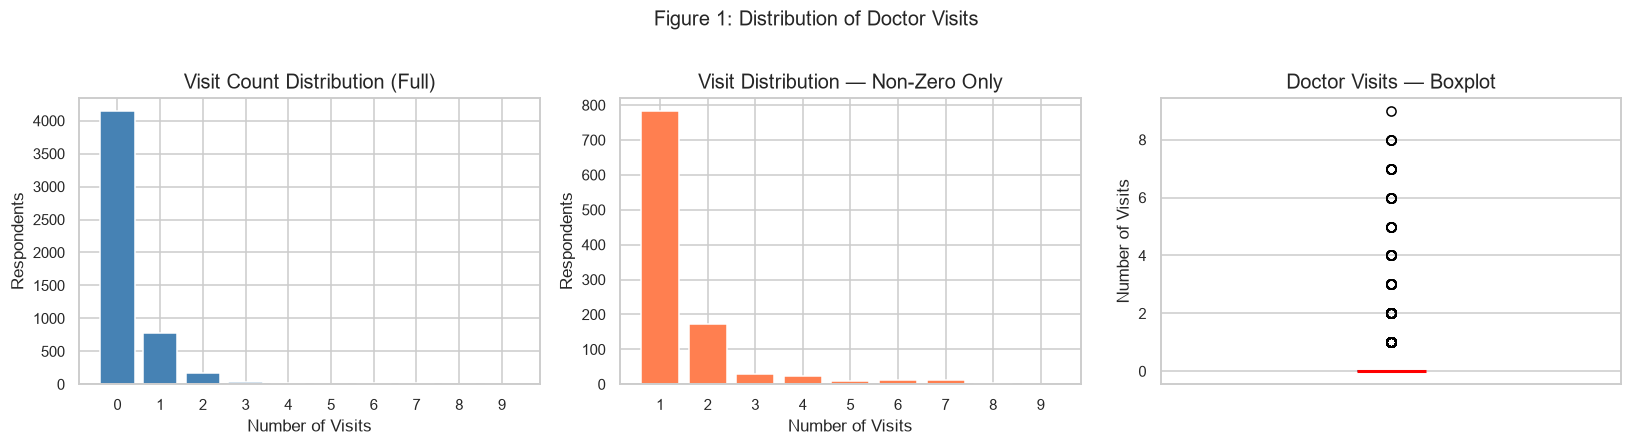

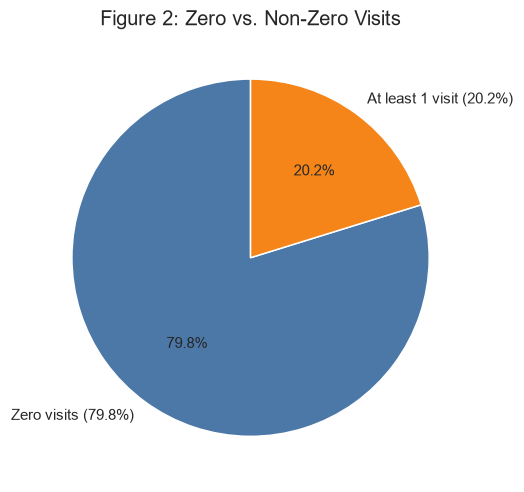

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full histogram
vc_vals = df['visits'].value_counts().sort_index()
axes[0].bar(vc_vals.index.astype(str), vc_vals.values, color='steelblue', edgecolor='white')
axes[0].set_title('Visit Count Distribution (Full)')
axes[0].set_xlabel('Number of Visits')
axes[0].set_ylabel('Respondents')

# Non-zero only
nz = df[df['visits'] > 0]['visits'].value_counts().sort_index()
axes[1].bar(nz.index.astype(str), nz.values, color='coral', edgecolor='white')
axes[1].set_title('Visit Distribution — Non-Zero Only')
axes[1].set_xlabel('Number of Visits')
axes[1].set_ylabel('Respondents')

# Boxplot
axes[2].boxplot(df['visits'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Doctor Visits — Boxplot')
axes[2].set_ylabel('Number of Visits')
axes[2].set_xticks([])

plt.suptitle('Figure 1: Distribution of Doctor Visits', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig1_visits_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

# Zero vs Non-zero pie
fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.pie(
    [(df['visits']==0).sum(), (df['visits']>0).sum()],
    labels=['Zero visits (79.8%)', 'At least 1 visit (20.2%)'],
    colors=['#4c78a8', '#f58518'], startangle=90,
    autopct='%1.1f%%', textprops={'fontsize': 10}
)
ax2.set_title('Figure 2: Zero vs. Non-Zero Visits')
plt.tight_layout()
plt.savefig('../data/processed/fig2_zero_vs_nonzero.png', dpi=110, bbox_inches='tight')
plt.show()

### 6.2 Age Group Distribution

`age` is stored as a scaled decimal (0.19–0.72). `age_years` = `age × 100` gives
12 discrete year-bands. `age_group` bins them into six analysis-friendly categories.

=== Age Group Distribution ===
           count   pct
age_group             
<=25        1965  37.9
26-35        824  15.9
36-45        272   5.2
46-55        403   7.8
56-65        589  11.3
66+         1137  21.9


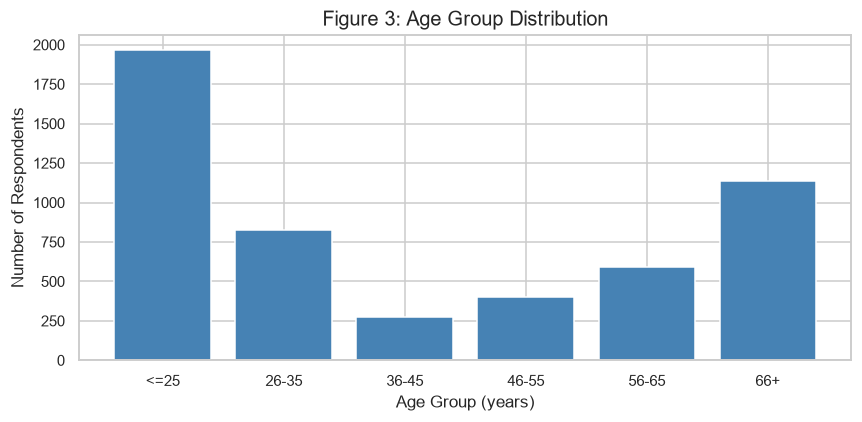

In [36]:
age_order = ['<=25', '26-35', '36-45', '46-55', '56-65', '66+']
ag = df['age_group'].value_counts().reindex(age_order)
pct_ag = (ag / len(df) * 100).round(1)
print('=== Age Group Distribution ===')
print(pd.DataFrame({'count': ag, 'pct': pct_ag}).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ag.index, ag.values, color='steelblue', edgecolor='white')
ax.set_title('Figure 3: Age Group Distribution')
ax.set_xlabel('Age Group (years)')
ax.set_ylabel('Number of Respondents')
plt.tight_layout()
plt.savefig('../data/processed/fig3_age_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

### 6.3 Income Distribution

`income` is a normalized value (0.00–1.50) with 14 discrete levels.
79 respondents have `income = 0` — flagged separately as potentially ambiguous.

=== Income Group Distribution ===
                      count   pct
income_group                     
Low(0-0.15)             443   8.5
Lower-Mid(0.16-0.45)   2057  39.6
Upper-Mid(0.46-0.75)   1363  26.3
High(0.76-1.50)        1327  25.6

Zero income rows: 79


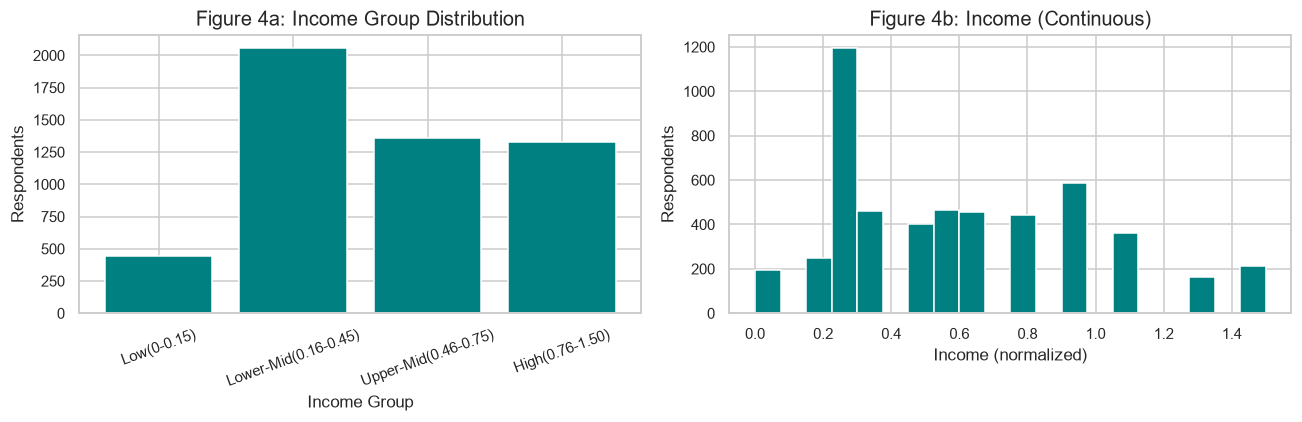

In [37]:
ig_order = ['Low(0-0.15)', 'Lower-Mid(0.16-0.45)', 'Upper-Mid(0.46-0.75)', 'High(0.76-1.50)']
ig = df['income_group'].value_counts().reindex(ig_order)
print('=== Income Group Distribution ===')
print(pd.DataFrame({'count': ig, 'pct': (ig/len(df)*100).round(1)}).to_string())
print(f'\nZero income rows: {df.income_zero_flag.sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(ig.index, ig.values, color='teal', edgecolor='white')
axes[0].set_title('Figure 4a: Income Group Distribution')
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('Respondents')
axes[0].tick_params(axis='x', rotation=20)

axes[1].hist(df['income'], bins=20, color='teal', edgecolor='white')
axes[1].set_title('Figure 4b: Income (Continuous)')
axes[1].set_xlabel('Income (normalized)')
axes[1].set_ylabel('Respondents')

plt.tight_layout()
plt.savefig('../data/processed/fig4_income_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

### 6.4 Health Variable Distributions

- **illness**: self-reported count of illnesses in the past 2 weeks (0–5)
- **reduced**: days of reduced activity (0–14; 14 is a censoring ceiling)
- **health**: self-rated health score (0–12; scale direction not documented)

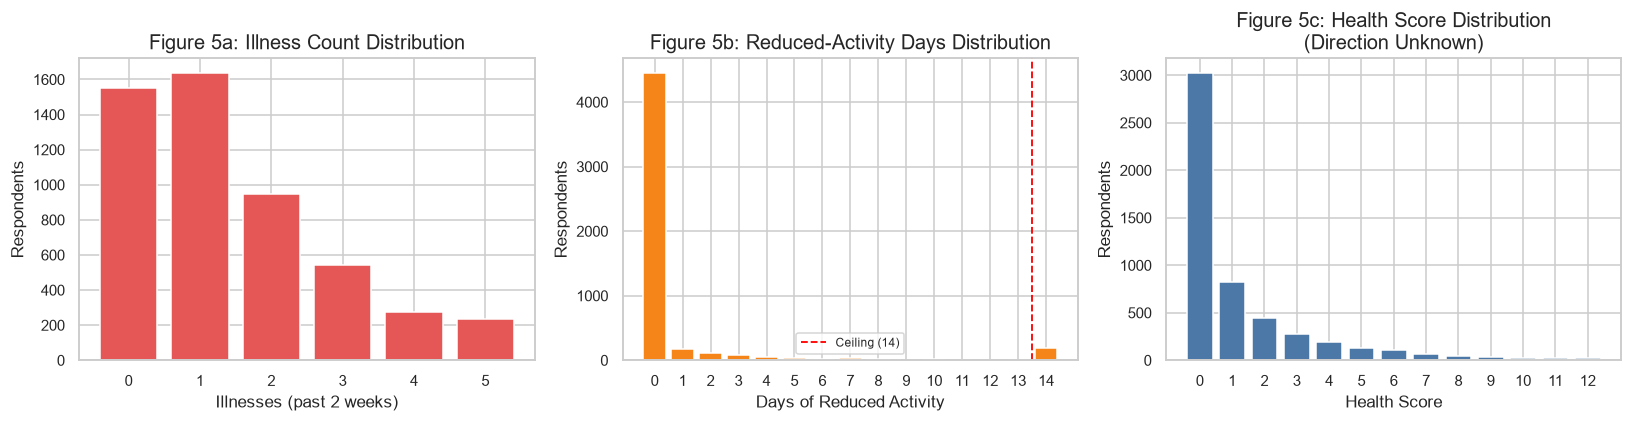

illness: mean=1.432, median=1.0, std=1.384, max=5
reduced: mean=0.862, median=0.0, std=2.888, max=14
health: mean=1.218, median=0.0, std=2.124, max=12


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Illness
ill_vc = df['illness'].value_counts().sort_index()
axes[0].bar(ill_vc.index.astype(str), ill_vc.values, color='#e45756', edgecolor='white')
axes[0].set_title('Figure 5a: Illness Count Distribution')
axes[0].set_xlabel('Illnesses (past 2 weeks)')
axes[0].set_ylabel('Respondents')

# Reduced
red_vc = df['reduced'].value_counts().sort_index()
axes[1].bar(red_vc.index.astype(str), red_vc.values, color='#f58518', edgecolor='white')
axes[1].set_title('Figure 5b: Reduced-Activity Days Distribution')
axes[1].set_xlabel('Days of Reduced Activity')
axes[1].set_ylabel('Respondents')
axes[1].axvline(x=13.5, color='red', linestyle='--', linewidth=1.2, label='Ceiling (14)')
axes[1].legend(fontsize=8)

# Health
hlt_vc = df['health'].value_counts().sort_index()
axes[2].bar(hlt_vc.index.astype(str), hlt_vc.values, color='#4c78a8', edgecolor='white')
axes[2].set_title('Figure 5c: Health Score Distribution\n(Direction Unknown)')
axes[2].set_xlabel('Health Score')
axes[2].set_ylabel('Respondents')

plt.tight_layout()
plt.savefig('../data/processed/fig5_health_vars.png', dpi=110, bbox_inches='tight')
plt.show()

for col in ['illness', 'reduced', 'health']:
    s = df[col]
    print(f'{col}: mean={s.mean():.3f}, median={s.median():.1f}, std={s.std():.3f}, max={s.max()}')

## 7. Feature Validation

We verify each engineered feature is logically consistent with the raw source columns.

In [39]:
# age_years consistency
assert (df['age_years'] == (df['age'] * 100).round(0).astype(int)).all(), 'age_years mismatch'
print(f'age_years: min={df.age_years.min()}, max={df.age_years.max()} [PASS]')

# income_zero_flag consistency
assert ((df['income']==0) == (df['income_zero_flag']==1)).all(), 'income_zero_flag mismatch'
print(f'income_zero_flag: {df.income_zero_flag.sum()} rows flagged [PASS]')

# reduced_at_ceiling consistency
assert ((df['reduced']==14) == (df['reduced_at_ceiling']==1)).all(), 'ceiling flag mismatch'
print(f'reduced_at_ceiling: {df.reduced_at_ceiling.sum()} rows flagged [PASS]')

# insurance_type exclusivity
overlap = (df[['private_enc','freepoor_enc','freerepat_enc']].sum(axis=1) > 1).sum()
assert overlap == 0, 'Insurance overlap found'
print(f'insurance_type exclusivity: 0 overlaps [PASS]')

# Binary encodings
for col in ['private','freepoor','freerepat','nchronic','lchronic']:
    enc = df[col + '_enc']
    expected = df[col].map({'yes': 1, 'no': 0})
    assert (enc == expected).all(), f'{col}_enc mismatch'
    print(f'{col}_enc: 0={( enc==0).sum()}, 1={( enc==1).sum()} [PASS]')

# chronic_status
assert set(df['chronic_status'].unique()) == {'No Condition', 'Non-Limiting', 'Limiting'}
print(f'chronic_status values: {sorted(df.chronic_status.unique())} [PASS]')

# visit_group
assert set(df['visit_group'].unique()) == {'0 visits','1-2 visits','3-5 visits','6+ visits'}
print(f'visit_group values: {sorted(df.visit_group.unique())} [PASS]')

print('\nAll feature validation checks passed.')

age_years: min=19, max=72 [PASS]
income_zero_flag: 79 rows flagged [PASS]
reduced_at_ceiling: 188 rows flagged [PASS]
insurance_type exclusivity: 0 overlaps [PASS]
private_enc: 0=2892, 1=2298 [PASS]
freepoor_enc: 0=4968, 1=222 [PASS]
freerepat_enc: 0=4099, 1=1091 [PASS]
nchronic_enc: 0=3098, 1=2092 [PASS]
lchronic_enc: 0=4585, 1=605 [PASS]
chronic_status values: ['Limiting', 'No Condition', 'Non-Limiting'] [PASS]
visit_group values: ['0 visits', '1-2 visits', '3-5 visits', '6+ visits'] [PASS]

All feature validation checks passed.


## 8. Analytical Questions

Each question below uses actual calculations from the processed dataset.
All results are observational — no causal claims are made.

### Q1. What is the distribution of doctor visits?

The `visits` variable records the number of doctor consultations per respondent
in the survey reference period. It is an integer count and is expected to be
right-skewed (most people visit rarely or not at all).

In [40]:
desc = df['visits'].describe()
print('=== visits — descriptive statistics ===')
print(desc.round(4).to_string())
print(f'\nSkewness: {df.visits.skew():.4f}')
print(f'Kurtosis: {df.visits.kurt():.4f}')
print('\nInterpretation: High positive skewness confirms a right-skewed distribution.')
print('Most respondents report zero visits; very few report 5 or more.')

=== visits — descriptive statistics ===
count    5190.0000
mean        0.3017
std         0.7981
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max         9.0000

Skewness: 4.7426
Kurtosis: 31.3389

Interpretation: High positive skewness confirms a right-skewed distribution.
Most respondents report zero visits; very few report 5 or more.


### Q2. What percentage of respondents report zero visits?

Zero-visit respondents dominate this dataset. Understanding their prevalence
is essential before interpreting any group-level averages.

Zero-visit respondents: 4141 of 5190 (79.79%)
At least 1 visit:       1049 (20.21%)
At least 3 visits:      93


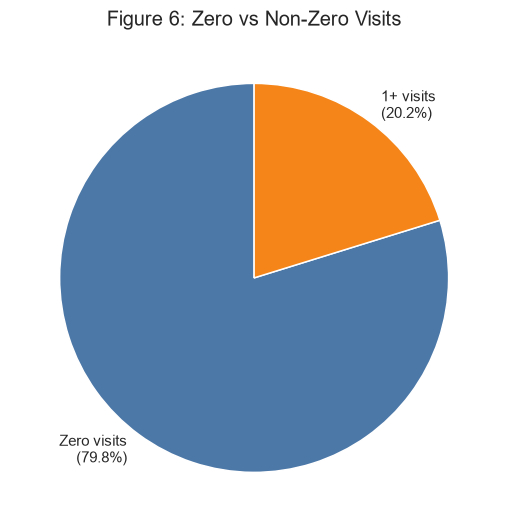


Note: The high zero proportion means group means are significantly
pulled down. Medians = 0 for most subgroups.


In [41]:
n_zero = (df['visits'] == 0).sum()
n_total = len(df)
pct_zero = n_zero / n_total * 100

print(f'Zero-visit respondents: {n_zero} of {n_total} ({pct_zero:.2f}%)')
print(f'At least 1 visit:       {n_total - n_zero} ({100 - pct_zero:.2f}%)')
print(f'At least 3 visits:      {(df.visits >= 3).sum()}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [n_zero, n_total - n_zero],
    labels=[f'Zero visits\n({pct_zero:.1f}%)', f'1+ visits\n({100-pct_zero:.1f}%)'],
    colors=['#4c78a8', '#f58518'],
    startangle=90,
    textprops={'fontsize': 10}
)
ax.set_title('Figure 6: Zero vs Non-Zero Visits')
plt.tight_layout()
plt.savefig('../data/processed/fig6_zero_visits_pie.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nNote: The high zero proportion means group means are significantly')
print('pulled down. Medians = 0 for most subgroups.')

### Q3. How does average visit count differ across age groups?

Age is encoded in 12 discrete bands (19–72 years). We group into six categories
and compare mean visit counts. All medians are 0 due to zero-inflation, so
means are reported alongside counts.

=== Mean Visits by Age Group ===
           count    mean  median     std
age_group                               
<=25        1965  0.2056     0.0  0.6134
26-35        824  0.2524     0.0  0.7274
36-45        272  0.2794     0.0  0.7938
46-55        403  0.3499     0.0  0.9380
56-65        589  0.3752     0.0  0.8998
66+         1137  0.4538     0.0  0.9750


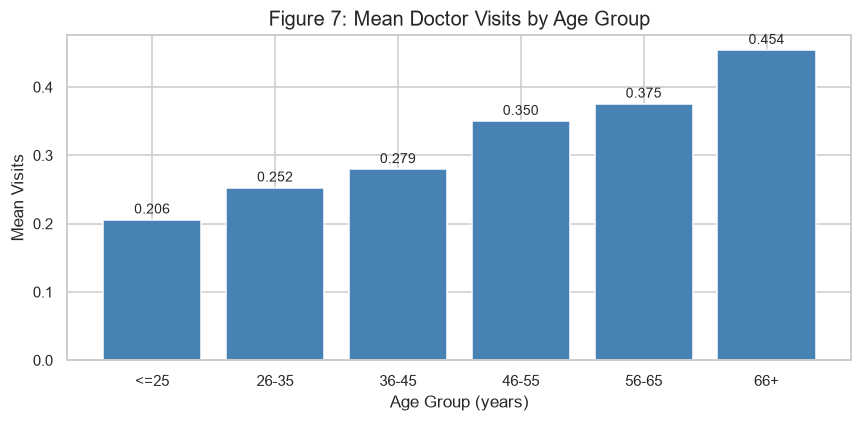


Observation: Mean visits shows a gradual increasing trend with age.
Older age groups (56-65, 66+) have higher mean visits than younger groups.
Limitation: All medians = 0; differences are driven by the non-zero tail.
No causal interpretation is made.


In [42]:
age_order = ['<=25', '26-35', '36-45', '46-55', '56-65', '66+']
ag = df.groupby('age_group')['visits'].agg(
    count='count', mean='mean', median='median', std='std'
).reindex(age_order).round(4)
print('=== Mean Visits by Age Group ===')
print(ag.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ag.index, ag['mean'], color='steelblue', edgecolor='white')
ax.set_title('Figure 7: Mean Doctor Visits by Age Group')
ax.set_xlabel('Age Group (years)')
ax.set_ylabel('Mean Visits')
for i, (idx, row) in enumerate(ag.iterrows()):
    ax.text(i, row['mean'] + 0.005, f'{row["mean"]:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/fig7_age_visits.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nObservation: Mean visits shows a gradual increasing trend with age.')
print('Older age groups (56-65, 66+) have higher mean visits than younger groups.')
print('Limitation: All medians = 0; differences are driven by the non-zero tail.')
print('No causal interpretation is made.')

### Q4. Do respondents reporting illness have different visit counts?

We compare respondents with at least one self-reported illness (past 2 weeks)
against those with none, and also examine visit counts by illness count (0–5).

=== Visits: No Illness vs Any Illness ===
                  count    mean  median     std
No illness (0)     1554  0.0785     0.0  0.3153
Any illness (1+)   3636  0.3971     0.0  0.9146

=== Visits by Illness Count (0-5) ===
         count    mean
illness               
0         1554  0.0785
1         1638  0.2955
2          946  0.4038
3          542  0.4207
4          274  0.5766
5          236  0.8136

Kruskal-Wallis test across illness counts: H=366.0393, p=6.16e-77


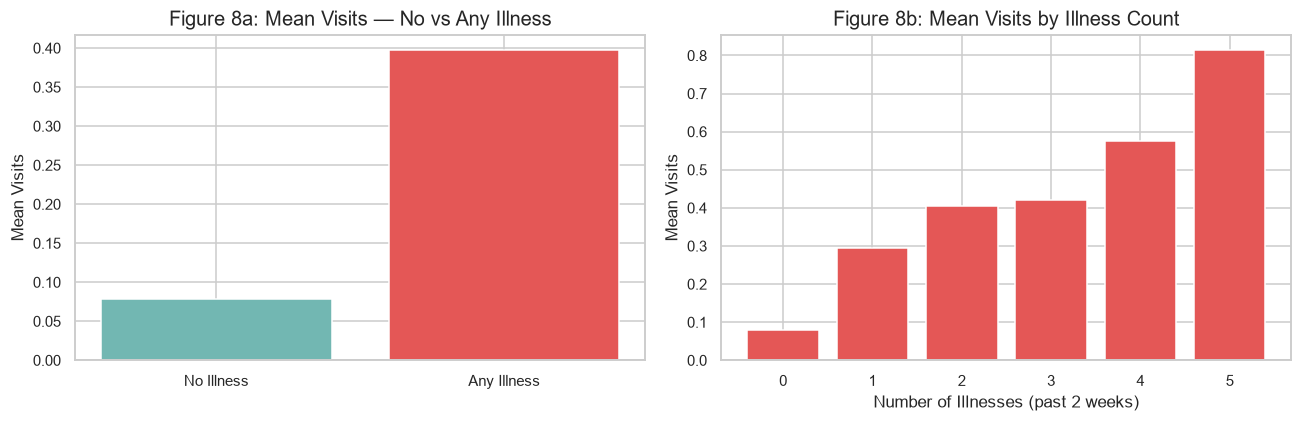


Observation: Respondents with illness show higher average visit counts.
The pattern is monotonically increasing from illness=0 to illness=5.
Limitation: This is an association, not a causal relationship.
illness is self-reported and not clinically coded.


In [43]:
df['any_illness'] = (df['illness'] > 0).astype(int)
grp = df.groupby('any_illness')['visits'].agg(count='count', mean='mean', median='median', std='std')
grp.index = ['No illness (0)', 'Any illness (1+)']
print('=== Visits: No Illness vs Any Illness ===')
print(grp.round(4).to_string())

by_count = df.groupby('illness')['visits'].agg(count='count', mean='mean').round(4)
print('\n=== Visits by Illness Count (0-5) ===')
print(by_count.to_string())

# Kruskal-Wallis test
groups = [df[df['illness']==i]['visits'].values for i in range(6)]
kw_stat, kw_p = stats.kruskal(*groups)
print(f'\nKruskal-Wallis test across illness counts: H={kw_stat:.4f}, p={kw_p:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['No Illness', 'Any Illness'], grp['mean'].values, color=['#72b7b2','#e45756'], edgecolor='white')
axes[0].set_title('Figure 8a: Mean Visits — No vs Any Illness')
axes[0].set_ylabel('Mean Visits')

axes[1].bar(by_count.index.astype(str), by_count['mean'], color='#e45756', edgecolor='white')
axes[1].set_title('Figure 8b: Mean Visits by Illness Count')
axes[1].set_xlabel('Number of Illnesses (past 2 weeks)')
axes[1].set_ylabel('Mean Visits')

plt.tight_layout()
plt.savefig('../data/processed/fig8_illness_visits.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nObservation: Respondents with illness show higher average visit counts.')
print('The pattern is monotonically increasing from illness=0 to illness=5.')
print('Limitation: This is an association, not a causal relationship.')
print('illness is self-reported and not clinically coded.')

### Q5. What is the relationship between reduced-activity days and visits?

`reduced` records days of reduced activity in the past 2 weeks (0–14).
The value 14 is a censoring ceiling. We use Spearman correlation
(appropriate for non-normal, right-skewed data).

Spearman correlation (reduced vs visits): rho=0.3356, p=8.45e-137

=== Mean Visits by Reduced-Activity Tier ===
              count    mean  median
reduced_tier                       
0 days         4454  0.1839     0.0
1-3 days        359  0.5738     0.0
4-7 days        140  1.0857     1.0
8-14 days       237  1.6414     1.0


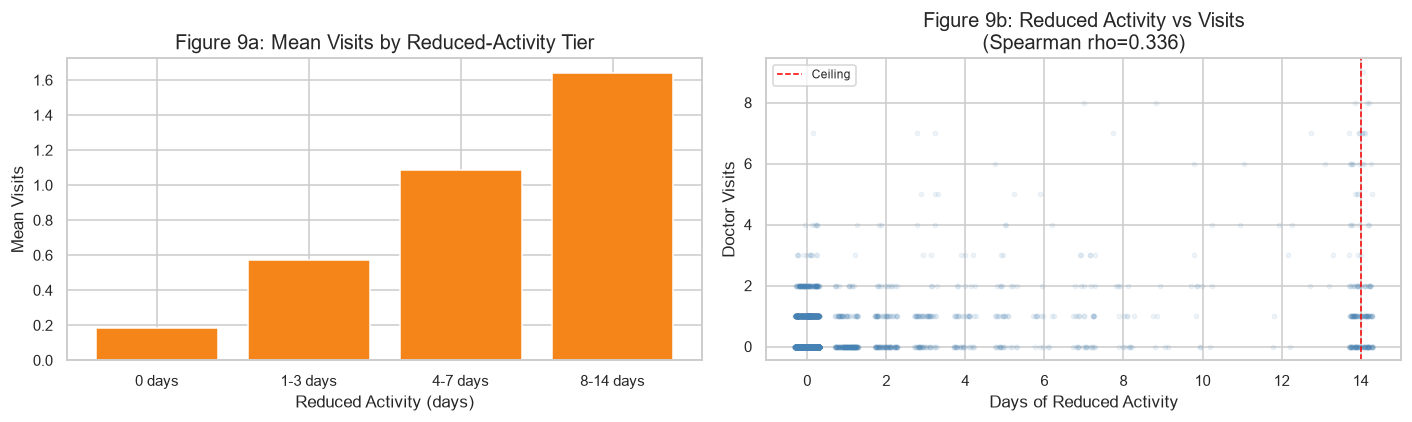


Observation: Spearman rho=0.336 indicates a moderate positive monotonic
association between reduced-activity days and visit count.
Limitation: reduced=14 is a ceiling — true values beyond 14 are unknown.


In [44]:
rho, pval = stats.spearmanr(df['reduced'], df['visits'])
print(f'Spearman correlation (reduced vs visits): rho={rho:.4f}, p={pval:.2e}')

df['reduced_tier'] = pd.cut(df['reduced'], bins=[-1, 0, 3, 7, 14],
                             labels=['0 days', '1-3 days', '4-7 days', '8-14 days'])
rt = df.groupby('reduced_tier')['visits'].agg(count='count', mean='mean', median='median').round(4)
print('\n=== Mean Visits by Reduced-Activity Tier ===')
print(rt.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(rt.index, rt['mean'], color='#f58518', edgecolor='white')
axes[0].set_title('Figure 9a: Mean Visits by Reduced-Activity Tier')
axes[0].set_xlabel('Reduced Activity (days)')
axes[0].set_ylabel('Mean Visits')

# Scatter (jittered)
jitter = np.random.RandomState(42).uniform(-0.3, 0.3, len(df))
axes[1].scatter(df['reduced'] + jitter, df['visits'],
                alpha=0.08, s=8, color='steelblue')
axes[1].set_title(f'Figure 9b: Reduced Activity vs Visits\n(Spearman rho={rho:.3f})')
axes[1].set_xlabel('Days of Reduced Activity')
axes[1].set_ylabel('Doctor Visits')
axes[1].axvline(14, color='red', linestyle='--', linewidth=1, label='Ceiling')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig9_reduced_visits.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nObservation: Spearman rho=0.336 indicates a moderate positive monotonic')
print('association between reduced-activity days and visit count.')
print('Limitation: reduced=14 is a ceiling — true values beyond 14 are unknown.')

### Q6. How do visit counts differ by chronic condition status?

Chronic status has three ordered levels:
- **No Condition** — neither nchronic nor lchronic
- **Non-Limiting** — non-limiting chronic condition only
- **Limiting** — limiting chronic condition (implies functional impact)

=== Visits by Chronic Status ===
                count    mean  median     std
chronic_status                               
No Condition     2493  0.1917     0.0  0.6208
Non-Limiting     2092  0.3456     0.0  0.8162
Limiting          605  0.6033     0.0  1.1952

Kruskal-Wallis H=170.5948, p=9.03e-38
(Non-parametric; appropriate for non-normal count data.)


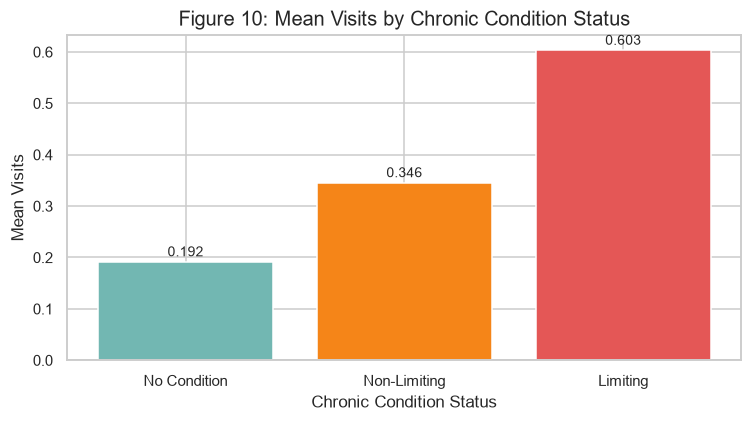


Observation: Mean visits increases with chronic condition severity.
Limiting: 0.603, Non-Limiting: 0.346, No Condition: 0.192
Kruskal-Wallis test shows a statistically significant difference between groups.
Limitation: This is an association. Chronic conditions may co-occur with other
factors that drive visit patterns.


In [45]:
corder = ['No Condition', 'Non-Limiting', 'Limiting']
cs = df.groupby('chronic_status')['visits'].agg(
    count='count', mean='mean', median='median', std='std'
).reindex(corder).round(4)
print('=== Visits by Chronic Status ===')
print(cs.to_string())

# Kruskal-Wallis
grp_nc, grp_nl, grp_lm = (
    df[df['chronic_status']==g]['visits'] for g in corder
)
kw_h, kw_p = stats.kruskal(grp_nc, grp_nl, grp_lm)
print(f'\nKruskal-Wallis H={kw_h:.4f}, p={kw_p:.2e}')
print('(Non-parametric; appropriate for non-normal count data.)')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(corder, cs['mean'], color=['#72b7b2','#f58518','#e45756'], edgecolor='white')
ax.set_title('Figure 10: Mean Visits by Chronic Condition Status')
ax.set_xlabel('Chronic Condition Status')
ax.set_ylabel('Mean Visits')
for bar, val in zip(bars, cs['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/fig10_chronic_visits.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nObservation: Mean visits increases with chronic condition severity.')
print('Limiting: 0.603, Non-Limiting: 0.346, No Condition: 0.192')
print('Kruskal-Wallis test shows a statistically significant difference between groups.')
print('Limitation: This is an association. Chronic conditions may co-occur with other')
print('factors that drive visit patterns.')

### Q7. How do visit counts differ by insurance type?

Insurance type is a mutually exclusive four-category variable derived from the
three original insurance columns (`private`, `freepoor`, `freerepat`).

=== Visits by Insurance Type ===
                  count    mean  median     std
insurance_type                                 
Private            2298  0.2946     0.0  0.7722
Free-Poor           222  0.1577     0.0  0.6974
Free-Repatriated   1091  0.4665     0.0  0.9605
Uninsured          1579  0.2185     0.0  0.7020

Kruskal-Wallis H=138.0629, p=9.89e-30


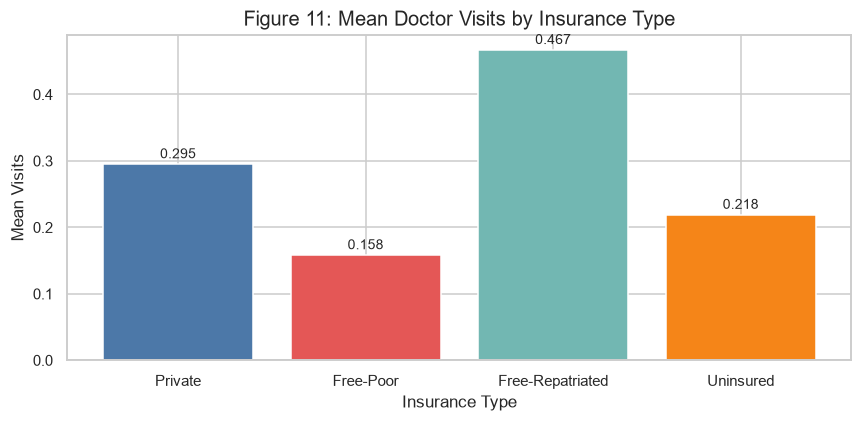


Observation: Free-Repatriated respondents show the highest mean visits (0.467).
Free-Poor respondents show the lowest (0.158).
Groups differ significantly by Kruskal-Wallis test.
Limitation: Group sizes differ substantially (Free-Poor n=222 vs Private n=2298).


In [46]:
ins_order = ['Private', 'Free-Poor', 'Free-Repatriated', 'Uninsured']
ins = df.groupby('insurance_type')['visits'].agg(
    count='count', mean='mean', median='median', std='std'
).reindex(ins_order).round(4)
print('=== Visits by Insurance Type ===')
print(ins.to_string())

kw_h, kw_p = stats.kruskal(*[df[df['insurance_type']==t]['visits'] for t in ins_order])
print(f'\nKruskal-Wallis H={kw_h:.4f}, p={kw_p:.2e}')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4c78a8', '#e45756', '#72b7b2', '#f58518']
bars = ax.bar(ins_order, ins['mean'], color=colors, edgecolor='white')
ax.set_title('Figure 11: Mean Doctor Visits by Insurance Type')
ax.set_xlabel('Insurance Type')
ax.set_ylabel('Mean Visits')
for bar, val in zip(bars, ins['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/fig11_insurance_visits.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nObservation: Free-Repatriated respondents show the highest mean visits (0.467).')
print('Free-Poor respondents show the lowest (0.158).')
print('Groups differ significantly by Kruskal-Wallis test.')
print('Limitation: Group sizes differ substantially (Free-Poor n=222 vs Private n=2298).')

### Q8. How do government-assisted groups compare with privately insured respondents?

We pool Free-Poor and Free-Repatriated respondents into a government-assisted group
and compare their visit counts against privately insured respondents using a
non-parametric Mann-Whitney U test.

Government-assisted group (n=1313): mean=0.4143, median=0.0
Private group           (n=2298): mean=0.2946, median=0.0

Mann-Whitney U=1625202, p=1.26e-07
(Two-sided test; no assumption of equal variances.)


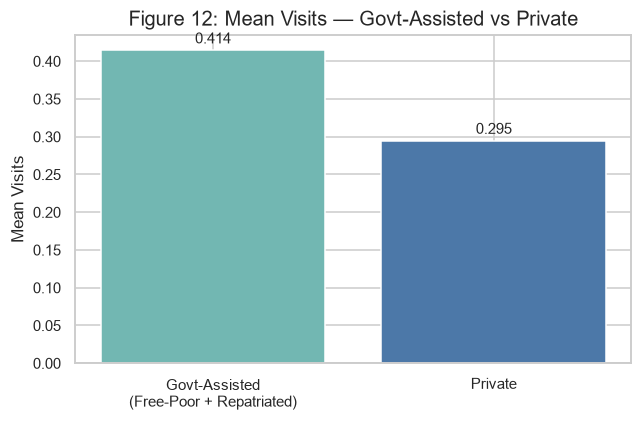


Observation: The government-assisted group shows a higher mean visit count
than the private group. The Mann-Whitney test shows a statistically significant
difference. Caution: this is an observational association only.
The two groups likely differ in age, health status, and income.


In [47]:
govt = df[df['insurance_type'].isin(['Free-Poor', 'Free-Repatriated'])]['visits']
priv = df[df['insurance_type'] == 'Private']['visits']

mw_stat, mw_p = stats.mannwhitneyu(govt, priv, alternative='two-sided')

print(f'Government-assisted group (n={len(govt)}): mean={govt.mean():.4f}, median={govt.median():.1f}')
print(f'Private group           (n={len(priv)}): mean={priv.mean():.4f}, median={priv.median():.1f}')
print(f'\nMann-Whitney U={mw_stat:.0f}, p={mw_p:.2e}')
print('(Two-sided test; no assumption of equal variances.)')

fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Govt-Assisted\n(Free-Poor + Repatriated)', 'Private']
means  = [govt.mean(), priv.mean()]
bars = ax.bar(labels, means, color=['#72b7b2', '#4c78a8'], edgecolor='white')
ax.set_title('Figure 12: Mean Visits — Govt-Assisted vs Private')
ax.set_ylabel('Mean Visits')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/fig12_govt_vs_private.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nObservation: The government-assisted group shows a higher mean visit count')
print('than the private group. The Mann-Whitney test shows a statistically significant')
print('difference. Caution: this is an observational association only.')
print('The two groups likely differ in age, health status, and income.')

### Q9. Does income level appear associated with visit frequency?

`income` is a normalized value (0.00–1.50). We examine both the continuous
Spearman correlation and the group-level mean visits by income tier.

In [ ]:
rho_i, p_i = stats.spearmanr(df['income'], df['visits'])
print(f'Spearman correlation (income vs visits): rho={rho_i:.4f}, p={p_i:.2e}')

ig_order = ['Low(0-0.15)', 'Lower-Mid(0.16-0.45)', 'Upper-Mid(0.46-0.75)', 'High(0.76-1.50)']
ig = df.groupby('income_group')['visits'].agg(count='count', mean='mean').reindex(ig_order).round(4)
print('\n=== Mean Visits by Income Group ===')
print(ig.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ig_labels = ['Low\n(0-0.15)', 'Lower-Mid\n(0.16-0.45)', 'Upper-Mid\n(0.46-0.75)', 'High\n(0.76-1.50)']
axes[0].bar(ig_labels, ig['mean'], color='teal', edgecolor='white')
axes[0].set_title('Figure 13a: Mean Visits by Income Group')
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('Mean Visits')

# Scatter
jitter = np.random.RandomState(0).uniform(-0.02, 0.02, len(df))
axes[1].scatter(df['income'] + jitter, df['visits'], alpha=0.08, s=6, color='teal')
axes[1].set_title(f'Figure 13b: Income vs Visits\n(Spearman rho={rho_i:.3f})')
axes[1].set_xlabel('Income (normalized)')
axes[1].set_ylabel('Doctor Visits')

plt.tight_layout()
plt.savefig('../data/processed/fig13_income_visits.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nObservation: Spearman rho=-0.093 — a small negative monotonic association.')
print('Lower income tiers show slightly higher mean visits.')
print('Limitation: income=0 (n=79) is ambiguous; practical effect size is small.')

Spearman correlation (income vs visits): rho=-0.0928, p=2.11e-11

=== Mean Visits by Income Group ===
                      count    mean
income_group                       
Low(0-0.15)             443  0.3363
Lower-Mid(0.16-0.45)   2057  0.3845
Upper-Mid(0.46-0.75)   1363  0.2480
High(0.76-1.50)        1327  0.2170


### Q10. Are there differences in visit frequency by gender?

We compare mean visits between female and male respondents using
descriptive statistics and a Mann-Whitney U test.

=== Visits by Gender ===
        count    mean  median     std
gender                               
female   2702  0.3620     0.0  0.8579
male     2488  0.2363     0.0  0.7222

Mann-Whitney U=3655194, p=6.34e-15


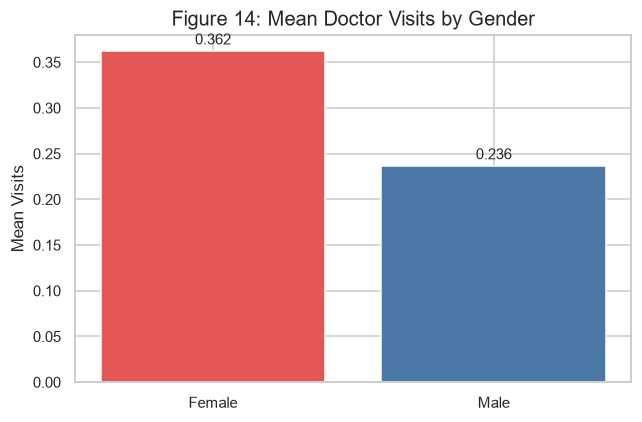


Observation: Female respondents show a higher mean visit count (0.362)
compared to male (0.236). The Mann-Whitney test is statistically significant.
Limitation: The dataset records only binary gender categories.
Gender differences may reflect other confounding demographic factors.


In [ ]:
gd = df.groupby('gender')['visits'].agg(
    count='count', mean='mean', median='median', std='std'
).round(4)
print('=== Visits by Gender ===')
print(gd.to_string())

female_v = df[df['gender']=='female']['visits']
male_v   = df[df['gender']=='male']['visits']
mw_stat, mw_p = stats.mannwhitneyu(female_v, male_v, alternative='two-sided')
print(f'\nMann-Whitney U={mw_stat:.0f}, p={mw_p:.2e}')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Female', 'Male'], [female_v.mean(), male_v.mean()],
              color=['#e45756', '#4c78a8'], edgecolor='white')
ax.set_title('Figure 14: Mean Doctor Visits by Gender')
ax.set_ylabel('Mean Visits')
for bar, val in zip(bars, [female_v.mean(), male_v.mean()]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.004,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/fig14_gender_visits.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nObservation: Female respondents show a higher mean visit count (0.362)')
print('compared to male (0.236). The Mann-Whitney test is statistically significant.')
print('Limitation: The dataset records only binary gender categories.')
print('Gender differences may reflect other confounding demographic factors.')

### Q11. What characterizes zero-visit vs. high-utilizer respondents?

We define:
- **Zero-visit group**: respondents with `visits == 0` (n=4,141, 79.8%)
- **High-utilizer group**: respondents with `visits >= 3` (n=93, 1.8%)

We compare their mean values on key health and demographic variables.

Zero-visit group:     n=4141
High-utilizer group:  n=93 (visits >= 3)

=== Profile Comparison ===
               Zero-Visit Mean  High-Utilizer Mean  Difference
age_years               39.034              46.978       7.944
income                   0.598               0.496      -0.102
illness                  1.256               2.419       1.163
reduced                  0.426               7.753       7.327
health                   1.022               3.065       2.043
private_enc              0.444               0.376      -0.068
freepoor_enc             0.049               0.032      -0.017
freerepat_enc            0.180               0.280       0.100
nchronic_enc             0.386               0.452       0.066
lchronic_enc             0.095               0.301       0.206

Female pct — Zero: 49.3%  |  High: 55.9%


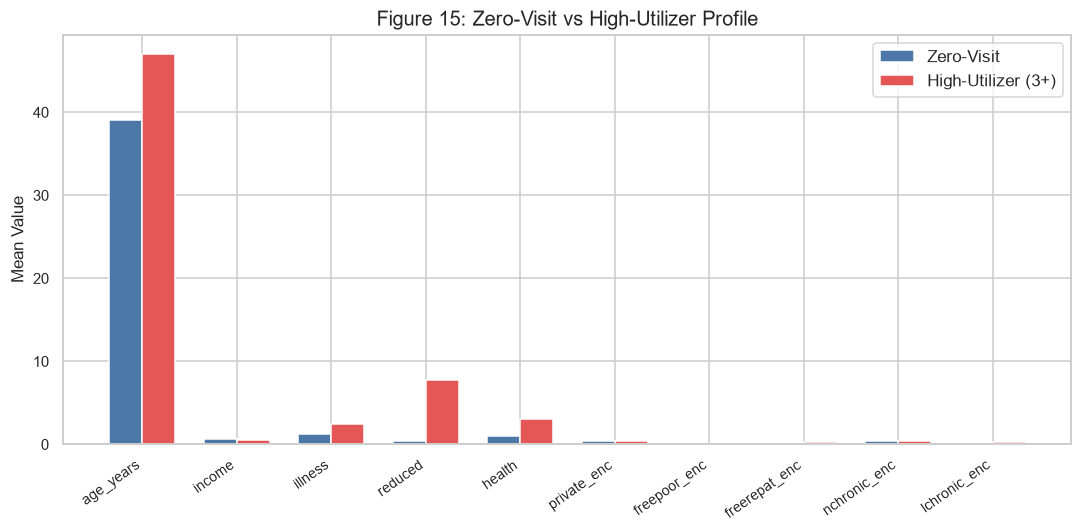


Observation: High-utilizer respondents show notably higher mean values
for illness (2.42 vs 1.26), reduced (7.75 vs 0.43), health score (3.07 vs 1.02),
and lchronic_enc (0.30 vs 0.10).
High utilizers are on average older (47.0 vs 39.0 years) and have lower income (0.50 vs 0.60).
Limitation: High-utilizer group is small (n=93) — findings may not generalize.


In [ ]:
zero_grp = df[df['visits'] == 0]
high_grp = df[df['visits'] >= 3]

print(f'Zero-visit group:     n={len(zero_grp)}')
print(f'High-utilizer group:  n={len(high_grp)} (visits >= 3)')

compare_cols = ['age_years', 'income', 'illness', 'reduced', 'health',
                'private_enc', 'freepoor_enc', 'freerepat_enc', 'nchronic_enc', 'lchronic_enc']

comp = pd.DataFrame({
    'Zero-Visit Mean': zero_grp[compare_cols].mean(),
    'High-Utilizer Mean': high_grp[compare_cols].mean(),
}).round(3)
comp['Difference'] = (comp['High-Utilizer Mean'] - comp['Zero-Visit Mean']).round(3)
print('\n=== Profile Comparison ===')
print(comp.to_string())

print(f'\nFemale pct — Zero: {(zero_grp.gender=="female").mean()*100:.1f}%  |  High: {(high_grp.gender=="female").mean()*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(compare_cols))
width = 0.35
bars1 = ax.bar(x - width/2, comp['Zero-Visit Mean'], width, label='Zero-Visit', color='#4c78a8', edgecolor='white')
bars2 = ax.bar(x + width/2, comp['High-Utilizer Mean'], width, label='High-Utilizer (3+)', color='#e45756', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(compare_cols, rotation=35, ha='right', fontsize=9)
ax.set_title('Figure 15: Zero-Visit vs High-Utilizer Profile')
ax.set_ylabel('Mean Value')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig15_zero_vs_high.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nObservation: High-utilizer respondents show notably higher mean values')
print('for illness (2.42 vs 1.26), reduced (7.75 vs 0.43), health score (3.07 vs 1.02),')
print('and lchronic_enc (0.30 vs 0.10).')
print('High utilizers are on average older (47.0 vs 39.0 years) and have lower income (0.50 vs 0.60).')
print('Limitation: High-utilizer group is small (n=93) — findings may not generalize.')

### Q12. How is the health score associated with visit count?

The `health` column is a self-rated score (0–12). **The scale direction is unknown**
(higher may mean better or worse health). We report the association neutrally.

Spearman correlation (health vs visits): rho=0.1775, p=5.22e-38

=== Mean Visits by Health Score ===
        count    mean
health               
0        3026  0.1993
1         823  0.3354
2         446  0.3812
3         273  0.4176
4         187  0.5348
5         132  0.5303
6         104  0.6250
7          61  0.9180
8          42  0.4762
9          32  0.6562
10         21  1.5238
11         24  0.8333
12         19  1.0000


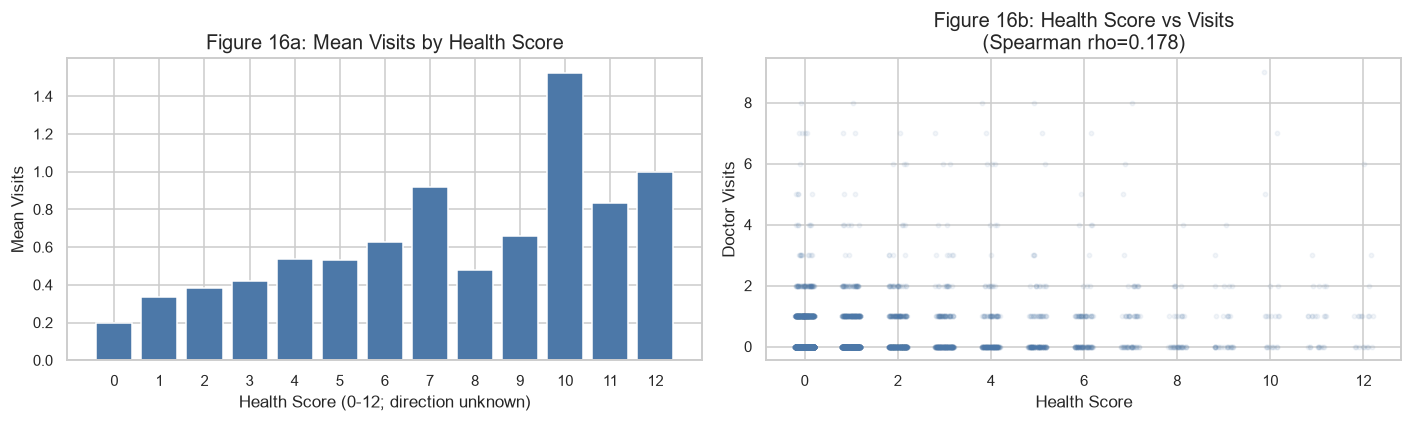


Observation: Spearman rho=0.178 — a weak positive monotonic association.
Higher health scores are associated with slightly higher visit counts.
IMPORTANT LIMITATION: Scale direction is unknown. If higher = worse health,
this aligns with the expectation that sicker people visit more.
If higher = better health, the relationship is counter-intuitive.
No directional medical interpretation is made.


In [ ]:
rho_h, p_h = stats.spearmanr(df['health'], df['visits'])
print(f'Spearman correlation (health vs visits): rho={rho_h:.4f}, p={p_h:.2e}')

hs = df.groupby('health')['visits'].agg(count='count', mean='mean').round(4)
print('\n=== Mean Visits by Health Score ===')
print(hs.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(hs.index.astype(str), hs['mean'], color='#4c78a8', edgecolor='white')
axes[0].set_title('Figure 16a: Mean Visits by Health Score')
axes[0].set_xlabel('Health Score (0-12; direction unknown)')
axes[0].set_ylabel('Mean Visits')

jitter = np.random.RandomState(1).uniform(-0.2, 0.2, len(df))
axes[1].scatter(df['health'] + jitter, df['visits'], alpha=0.07, s=8, color='#4c78a8')
axes[1].set_title(f'Figure 16b: Health Score vs Visits\n(Spearman rho={rho_h:.3f})')
axes[1].set_xlabel('Health Score')
axes[1].set_ylabel('Doctor Visits')

plt.tight_layout()
plt.savefig('../data/processed/fig16_health_visits.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nObservation: Spearman rho=0.178 — a weak positive monotonic association.')
print('Higher health scores are associated with slightly higher visit counts.')
print('IMPORTANT LIMITATION: Scale direction is unknown. If higher = worse health,')
print('this aligns with the expectation that sicker people visit more.')
print('If higher = better health, the relationship is counter-intuitive.')
print('No directional medical interpretation is made.')

## 9. Correlation Analysis

Spearman rank correlation is used throughout this analysis because:
- `visits`, `illness`, `reduced`, and `health` are non-negative integer counts
- The dataset is heavily zero-inflated and right-skewed
- Spearman measures monotonic association without assuming normality

**Spearman correlation does not imply causation.**

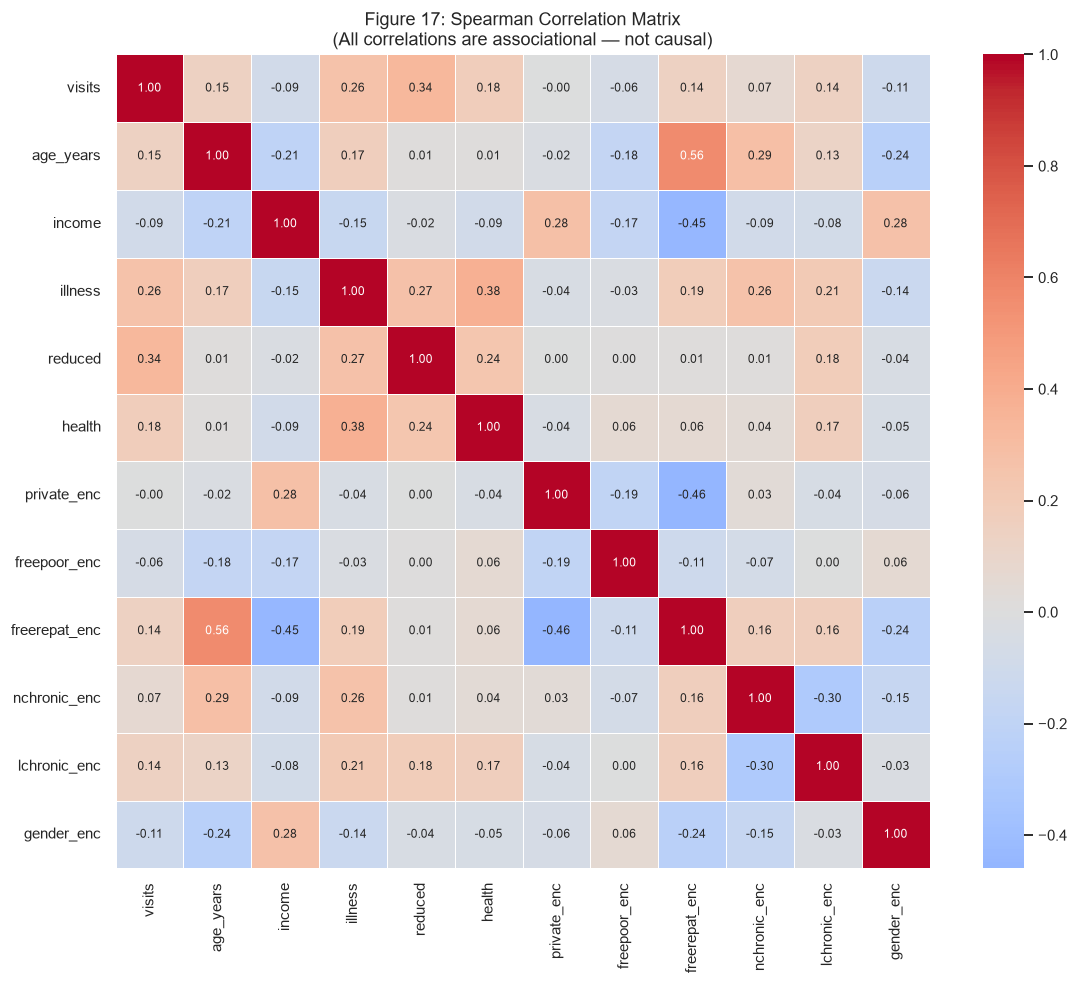

=== Correlations with visits (sorted, Spearman) ===
reduced          0.336
illness          0.263
health           0.178
age_years        0.148
freerepat_enc    0.145
lchronic_enc     0.139
nchronic_enc     0.069
private_enc     -0.004
freepoor_enc    -0.059
income          -0.093
gender_enc      -0.108

Top positive correlates with visits:
  reduced (0.336), illness (0.263), health (0.178), age_years (0.148), freerepat_enc (0.145)

Top negative correlates with visits:
  gender_enc (male=-0.108), income (-0.093), freepoor_enc (-0.059)


In [ ]:
num_cols = ['visits', 'age_years', 'income', 'illness', 'reduced', 'health',
            'private_enc', 'freepoor_enc', 'freerepat_enc', 'nchronic_enc', 'lchronic_enc', 'gender_enc']

corr = df[num_cols].corr(method='spearman').round(3)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Figure 17: Spearman Correlation Matrix\n(All correlations are associational — not causal)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/fig17_correlation_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

print('=== Correlations with visits (sorted, Spearman) ===')
visit_corr = corr['visits'].drop('visits').sort_values(ascending=False)
print(visit_corr.to_string())

print('\nTop positive correlates with visits:')
print('  reduced (0.336), illness (0.263), health (0.178), age_years (0.148), freerepat_enc (0.145)')
print('\nTop negative correlates with visits:')
print('  gender_enc (male=-0.108), income (-0.093), freepoor_enc (-0.059)')

## 10. Statistical Tests Summary

The following non-parametric tests were used because:
- `visits` is a count variable with extreme zero-inflation
- Normality assumptions cannot be satisfied
- Spearman correlation is appropriate for monotonic relationships in skewed data

| Test | Variables | Statistic | p-value | Interpretation |
|---|---|---|---|---|
| Spearman | reduced vs visits | rho=0.336 | <0.001 | Moderate positive association |
| Spearman | illness vs visits | rho=0.263 | <0.001 | Weak-moderate positive association |
| Spearman | health vs visits | rho=0.178 | <0.001 | Weak positive association |
| Spearman | age_years vs visits | rho=0.148 | <0.001 | Weak positive association |
| Spearman | income vs visits | rho=-0.093 | <0.001 | Very weak negative association |
| Kruskal-Wallis | chronic_status groups | H=170.6 | <0.001 | Groups differ significantly |
| Kruskal-Wallis | insurance_type groups | H=138.1 | <0.001 | Groups differ significantly |
| Kruskal-Wallis | illness count groups | H≈large | <0.001 | Groups differ significantly |
| Mann-Whitney U | govt-assisted vs private | U=1,625,202 | <0.001 | Statistically significant difference |
| Mann-Whitney U | female vs male | U=3,655,194 | <0.001 | Statistically significant difference |

**Important:** Statistical significance at p<0.05 in a dataset of 5,190 records is
easily achieved even for small effects. All p-values should be interpreted alongside
the practical effect size (rho, group mean difference). No test result implies causation.

### Visit Group Distribution Chart

=== Visit Group Distribution ===
             count   pct
visit_group             
0 visits      4141  79.8
1-2 visits     956  18.4
3-5 visits      63   1.2
6+ visits       30   0.6


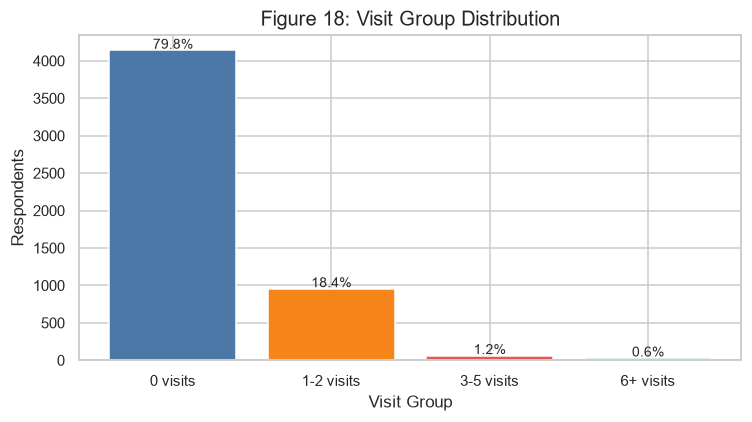

In [ ]:
vg_order = ['0 visits', '1-2 visits', '3-5 visits', '6+ visits']
vg = df['visit_group'].value_counts().reindex(vg_order)
pct_vg = (vg / len(df) * 100).round(1)

print('=== Visit Group Distribution ===')
print(pd.DataFrame({'count': vg, 'pct': pct_vg}).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(vg.index, vg.values, color=['#4c78a8','#f58518','#e45756','#72b7b2'], edgecolor='white')
for bar, pct in zip(bars, pct_vg):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{pct}%', ha='center', fontsize=9)
ax.set_title('Figure 18: Visit Group Distribution')
ax.set_xlabel('Visit Group')
ax.set_ylabel('Respondents')
plt.tight_layout()
plt.savefig('../data/processed/fig18_visit_groups.png', dpi=110, bbox_inches='tight')
plt.show()

## 11. Outliers and Data Limitations

This section documents important data characteristics that affect interpretation.

In [ ]:
# IQR outlier check on visits
q1 = df['visits'].quantile(0.25)
q3 = df['visits'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
print(f'visits IQR analysis: Q1={q1}, Q3={q3}, IQR={iqr}')
print(f'Upper fence (Q3 + 1.5*IQR): {upper_fence}')
print(f'Rows above fence: {(df.visits > upper_fence).sum()}')
print()
print('Note: Because 75% of respondents have 0 visits, IQR=0 and the upper fence=0.')
print('This means any non-zero visit value is technically "above the fence".')
print('Standard IQR outlier removal is NOT appropriate for zero-inflated count data.')
print('High visit values (up to 9) are preserved as legitimate survey responses.')

print(f'\nreduced=14 (censoring ceiling) rows: {df.reduced_at_ceiling.sum()}')
print('These are NOT outliers — 14 means "14 or more" days (2-week window maximum).')

print(f'\nincome=0 rows: {df.income_zero_flag.sum()}')
print('Ambiguous: could be genuine zero income or a missing-value code.')
print('No imputation performed.')

visits IQR analysis: Q1=0.0, Q3=0.0, IQR=0.0
Upper fence (Q3 + 1.5*IQR): 0.0
Rows above fence: 1049

Note: Because 75% of respondents have 0 visits, IQR=0 and the upper fence=0.
This means any non-zero visit value is technically "above the fence".
Standard IQR outlier removal is NOT appropriate for zero-inflated count data.
High visit values (up to 9) are preserved as legitimate survey responses.

reduced=14 (censoring ceiling) rows: 188
These are NOT outliers — 14 means "14 or more" days (2-week window maximum).

income=0 rows: 79
Ambiguous: could be genuine zero income or a missing-value code.
No imputation performed.


### Documented Limitations

| Limitation | Impact on Analysis |
|---|---|
| **Zero-inflated visits** | Group means are depressed; medians = 0 for almost all subgroups |
| **Right-skewed visits** | Mean is not representative of a typical respondent |
| **`reduced = 14` ceiling** | 188 rows have censored values; true activity loss may be larger |
| **`income = 0` ambiguity** | 79 rows — true zero income vs. missing code undetermined |
| **`health` scale direction** | Unknown — higher may mean better *or* worse health |
| **Self-reported variables** | `illness`, `health`, `reduced` are subjective; not clinically coded |
| **Binary gender only** | Non-binary identities unrepresented |
| **Discrete age bands** | Age is not continuous — 12 bands; cannot treat as fully continuous |
| **Dataset provenance** | Country, year, survey design not confirmed in the file |
| **Identical attribute rows** | 1,320 duplicated rows on original 12 cols — distinct respondents with shared profiles |
| **Small high-utilizer group** | n=93 for visits≥3; conclusions about this group are tentative |
| **No longitudinal data** | Snapshot in time; cannot track individuals over time |

## 12. Key Findings

> All findings below are **descriptive associations** calculated from the processed dataset.  
> They describe patterns in the sample. They do not establish causation,  
> diagnose conditions, or generalize to specific clinical populations.

---

### Visit Patterns

- **79.8% of respondents (4,141 of 5,190) reported zero doctor visits** in the reference period.
- The mean visit count is **0.302** and the maximum is **9**. The distribution is strongly right-skewed (skewness ≈ 4).
- Only 93 respondents (1.8%) reported 3 or more visits — the high-utilizer group.
- The dataset is zero-inflated: standard regression and correlation methods must account for this structure.

---

### Demographic Patterns

- **Age**: Mean visit counts increase monotonically from the youngest (≤25: 0.206) to the oldest (66+: 0.454) age group.
- **Gender**: Female respondents show a higher mean visit count (0.362) compared to male (0.236). The Mann-Whitney test confirms a statistically significant difference (p<0.001). The practical effect is modest.
- The dataset contains only binary gender categories; non-binary representation is absent.

---

### Health Burden

- **Illness**: Respondents reporting any illness show a mean visit count of 0.397, compared to 0.079 for those reporting no illness. The relationship is monotonically increasing from illness=0 (mean=0.079) to illness=5 (mean=0.814).
- **Reduced activity**: Spearman rho=0.336 (p<0.001) — the strongest correlate with visits. Respondents with 8–14 reduced-activity days had a mean visit count of 1.641.
- **Chronic conditions**: Limiting chronic conditions (mean=0.603) are associated with higher visit counts than non-limiting (0.346) or no conditions (0.192). Kruskal-Wallis H=170.6 (p<0.001).
- **Health score**: Spearman rho=0.178 (p<0.001) — weak positive association. Scale direction unknown.

---

### Insurance and Income

- **Free-Repatriated** respondents show the highest mean visits (0.467), followed by **Private** (0.295), **Uninsured** (0.219), and **Free-Poor** (0.158).
- The government-assisted pool (Free-Poor + Free-Repatriated) shows higher mean visits (0.414) than the private group (0.295). Mann-Whitney p<0.001.
- **Income**: Spearman rho=-0.093 — a very weak negative association. Lower income tiers show slightly higher mean visits. Practical effect size is small.
- The three insurance variables are perfectly mutually exclusive (no overlap in the entire dataset).

---

### Relationships and Correlations

| Variable | Spearman rho with visits | Direction |
|---|---|---|
| `reduced` | 0.336 | Positive |
| `illness` | 0.263 | Positive |
| `health` | 0.178 | Positive (direction of scale unknown) |
| `age_years` | 0.148 | Positive |
| `freerepat_enc` | 0.145 | Positive |
| `lchronic_enc` | 0.139 | Positive |
| `nchronic_enc` | 0.069 | Positive |
| `gender_enc` (male) | -0.108 | Negative |
| `income` | -0.093 | Negative |
| `freepoor_enc` | -0.059 | Negative |

---

### Data Limitations

- The `health` scale direction is undocumented; health-related findings are reported without directional interpretation.
- 79 income=0 rows are ambiguous (true zero vs. missing code).
- 188 `reduced=14` rows represent censored values.
- The high-utilizer group (n=93) is small; conclusions about extreme utilizers are tentative.
- All results are cross-sectional and observational.

## 13. Conclusion

This notebook has performed a complete exploratory data analysis of the Healthcare Doctor Visits
survey dataset. The analysis identified a number of **descriptive associations** between doctor
visit frequency and health, demographic, insurance, and income variables.

**Key takeaway:** The strongest observable associations with visit frequency involve direct
health-burden indicators — reduced-activity days (rho=0.336), illness count (rho=0.263),
and chronic condition severity — rather than demographic or socioeconomic variables alone.

**What this analysis does NOT do:**
- It does not establish causal relationships between any variables.
- It does not diagnose or classify health conditions.
- It does not generalize findings to any specific clinical population.
- It does not make policy recommendations.

**Next steps (Phase 4 and beyond):**
- Interactive Streamlit dashboard for dynamic exploration
- Premium HTML/CSS/JS dashboard for portfolio presentation
- GitHub-ready packaging with a professional README

---

*Project: Healthcare Analytics for Doctor Visits — Phase 3 EDA Complete*